<a href="https://colab.research.google.com/github/mrbedoya/ml-2026/blob/main/19_EvaluacionEntreModelosClasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación entre diferentes Modelos de Clasificación

## 1. Librerias y configuraciones previas


In [22]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np


# Almacenar en caché los resultados de funciones en el disco
# ==============================================================================
import joblib
import os


# Gestion de librerias
# ==============================================================================
from importlib import reload


# Matemáticas y estadísticas
# ==============================================================================
import math

# Preprocesado y modelado
# ==============================================================================

# Preparación de datos
from sklearn.neighbors import LocalOutlierFactor

#Separar los datos entrenamiento y prueba
from sklearn.model_selection import train_test_split

#Escalar Variables
from sklearn.preprocessing import MinMaxScaler

#Evaluación del modelo
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

#configuracion de hiperparámetros
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Interuactuar con os y solicitudes desde HTTP
# ==============================================================================
import os
import sys
import requests

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [23]:
# Parametros globales
# ==============================================================================

# Construimos la URL de la API de GitHub para el directorio de modelos
# El formato es: https://api.github.com/repos/{owner}/{repo}/contents/{path}
api_url = "https://api.github.com/repos/mrbedoya/ml-2026/contents/modelos/clasificacion"

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/mrbedoya/ml-2026/main/'

# Nombres de los archivos requeridos
DATASET_FILE_NAME_PRUE = '02_GermanCredit_Prue.csv'
DATASET_FILE_NAME_PREP = '02_GermanCredit_Prep.csv'
UTILS_FILE_NAME = 'funciones.py'
SCALER_FILE_NAME = 'minmaxFull_GermanCredits.pkl'

# Nombres de los directorios para utilidades, datasets y modelos
DATASETS_PATH = 'datasets/'
UTILS_PATH = 'utils/'
MODELS_PATH = 'modelos/'
MODELS_CLASIFICATION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH = os.path.join(MODELS_PATH, 'scaler')

# URL completa del dataset y utils en GitHub
github_dataset_url_prue = os.path.join(GITHUB_BASE_URL, DATASETS_PATH, DATASET_FILE_NAME_PRUE)
github_dataset_url_prep = os.path.join(GITHUB_BASE_URL, DATASETS_PATH, DATASET_FILE_NAME_PREP)
github_utils_url = os.path.join(GITHUB_BASE_URL, UTILS_PATH, UTILS_FILE_NAME)
github_scaler_url = os.path.join(GITHUB_BASE_URL, MODELS_SCALER_PATH, SCALER_FILE_NAME)

# Rutas locales completas de datasets y utils
local_dataset_path_prue = os.path.join(DATASETS_PATH, DATASET_FILE_NAME_PRUE)
local_dataset_path_prep = os.path.join(DATASETS_PATH, DATASET_FILE_NAME_PREP)
local_utils_path = os.path.join(UTILS_PATH, UTILS_FILE_NAME)
local_scaler_path = os.path.join(MODELS_SCALER_PATH, SCALER_FILE_NAME)

In [24]:
## Cargar datos desde Google Drive
## ==============================================================================

#from google.colab import drive

## Montar Google Drive
#drive.mount('/gdrive')

## Establece el directorio de trabajo dentro de directorio espefíficado en Google Drive
#os.chdir("/gdrive/MyDrive/01_Academia/02_Cursos/20260401_ApredinzajeAutomáticoI_UdeA/")

## Listar archivos de directorio
##!ls

In [25]:
# Funcion local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.

    Args:
        url (str): URL del archivo
        path (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f"Descargando {description} desde: {url}")

    # Realiza una solicitud HTTP GET a la URL proporcionada
    response = requests.get(url)

    # Lanza una excepción si la descarga falla (código de estado HTTP no 200)
    response.raise_for_status()

    # Abre el archivo local en modo de escritura binaria ('wb')
    with open(path, 'wb') as f:
        # Escribe el contenido binario de la respuesta HTTP en el archivo local
        f.write(response.content)

    # Imprime un mensaje confirmando que la descarga fue exitosa y la ruta de guardado
    print(f"{description} descargado exitosamente a: {path}")

In [26]:
# Creación de directorios locales
os.makedirs(DATASETS_PATH, exist_ok=True)
os.makedirs(UTILS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# Crear subdirectorios específicos para modelos y escalados
os.makedirs(MODELS_CLASIFICATION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH, exist_ok=True)

# Descarga de archivos
download_file(github_dataset_url_prue, local_dataset_path_prue, "dataset")
download_file(github_dataset_url_prep, local_dataset_path_prep, "dataset")
download_file(github_utils_url, local_utils_path, "funciones")
download_file(github_scaler_url,local_scaler_path, "scaler")

Descargando dataset desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/datasets/02_GermanCredit_Prue.csv
dataset descargado exitosamente a: datasets/02_GermanCredit_Prue.csv
Descargando dataset desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/datasets/02_GermanCredit_Prep.csv
dataset descargado exitosamente a: datasets/02_GermanCredit_Prep.csv
Descargando funciones desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/utils/funciones.py
funciones descargado exitosamente a: utils/funciones.py
Descargando scaler desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/modelos/scaler/minmaxFull_GermanCredits.pkl
scaler descargado exitosamente a: modelos/scaler/minmaxFull_GermanCredits.pkl


In [27]:
# Obtener la lista de archivos desde la API de GitHub
# ==============================================================================

print(f"Consultando lista de modelos en: {api_url}")
response = requests.get(api_url)
response.raise_for_status()

# Filtrar solo archivos .pkl
repo_contents = response.json()
model_file_names = [file['name'] for file in repo_contents if file['name'].endswith('.pkl')]

print(f"Modelos encontrados: {model_file_names}")

# Descargar cada modelo encontrado
for model_name in model_file_names:
    github_model_url = os.path.join(GITHUB_BASE_URL, MODELS_CLASIFICATION_PATH, model_name)
    local_model_path = os.path.join(MODELS_CLASIFICATION_PATH, model_name)
    download_file(github_model_url, local_model_path, f"modelo {model_name}")

Consultando lista de modelos en: https://api.github.com/repos/mrbedoya/ml-2026/contents/modelos/clasificacion
Modelos encontrados: ['AdaB_CV.pkl', 'DTreeC_CV.pkl', 'GBoost_CV.pkl', 'KNN_CV_manhattan.pkl', 'LRLineaB.pkl', 'NB_Ret_Bernulli.pkl', 'RForest_CV.pkl', 'SVC_CV_lineal.pkl', 'SVC_CV_poly.pkl', 'SVC_CV_rbf.pkl']
Descargando modelo AdaB_CV.pkl desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/modelos/clasificacion/AdaB_CV.pkl
modelo AdaB_CV.pkl descargado exitosamente a: modelos/clasificacion/AdaB_CV.pkl
Descargando modelo DTreeC_CV.pkl desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/modelos/clasificacion/DTreeC_CV.pkl
modelo DTreeC_CV.pkl descargado exitosamente a: modelos/clasificacion/DTreeC_CV.pkl
Descargando modelo GBoost_CV.pkl desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/modelos/clasificacion/GBoost_CV.pkl
modelo GBoost_CV.pkl descargado exitosamente a: modelos/clasificacion/GBoost_CV.pkl
Descargando modelo KNN_CV_manhattan.pkl 

## 2. Funciones

In [28]:
## Funciones externas
# ==============================================================================

## Añade la ruta definida en 'UTILS_PATH' al 'sys.path' para que Python pueda encontrar módulos
sys.path.append(UTILS_PATH)

## Importar Funciones externas
from utils.funciones import multiple_plot, plot_roc_curve

## 3. Carga del dataset

In [29]:
#Carga del dataset

dp=pd.read_csv(local_dataset_path_prue)
dp.shape

(100, 21)

In [30]:
dp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   checking_account_status   100 non-null    object
 1   loan_duration_mo          100 non-null    int64 
 2   credit_history            100 non-null    object
 3   purpose                   100 non-null    object
 4   loan_amount               100 non-null    int64 
 5   savings_account_balance   100 non-null    object
 6   time_employed_yrs         100 non-null    object
 7   payment_pcnt_income       100 non-null    int64 
 8   gender_status             100 non-null    object
 9   other_signators           100 non-null    object
 10  time_in_residence         100 non-null    int64 
 11  property                  100 non-null    object
 12  age_yrs                   100 non-null    int64 
 13  other_credit_outstanding  100 non-null    object
 14  home_ownership            1

## 4. Visualización de datos

### Variables de entrada

In [31]:
#Lista de variables categóricas
catCols = dp.select_dtypes(include = ["object", 'category']).columns.tolist()

dp[catCols].head(2)

,checking_account_status,credit_history,purpose,savings_account_balance,time_employed_yrs,gender_status,other_signators,property,other_credit_outstanding,home_ownership,job_category,telephone,foreign_worker
0,none,critical account - other non-bank loans,education,< 100 DM,4 - 7 years,male-single,none,real estate,none,own,unskilled-resident,none,yes
1,< 0 DM,no credit - paid,business,unknown/none,< 1 year,male-single,none,car or other,bank,own,skilled,none,yes


In [32]:
#Lista de variables numéricas

numCols=dp.select_dtypes(include = ['float64','float64','int32','int64']).columns.tolist()

dp[numCols].head(2)

,loan_duration_mo,loan_amount,payment_pcnt_income,time_in_residence,age_yrs,number_loans,dependents,bad_credit
0,12,2096,2,3,49,1,2,0
1,30,8072,2,3,25,3,1,0


In [33]:
## Visualización de frecuencia de instancias para variables categóricas
#multiple_plot(3, dp , catCols, None, 'countplot', 'Frecuencia de instancias para variables categóricas',30)

In [34]:
## Visualización de variables numéricas
#multiple_plot(1, dp , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)

In [35]:
#Eliminar la variable de salida de la lista de variable numéricas
numCols.remove('bad_credit')

### Variable de salida

In [36]:
# Distriución de la variable de salida

dp.groupby('bad_credit').bad_credit.count().sort_values(ascending=False)

,bad_credit
bad_credit,
0,71
1,29


In [37]:
##Visualización de la variable de salida
#multiple_plot(1, d , None, 'bad_credit', 'countplot', 'Gráfica de frecuencia de bad Credit',0)

## 5. Transformación de datos

### Valores atípicos para las variables de entrada

In [38]:
#utilización de LocalOutlierFactor con 13 vecinos para identificar valores atípicos en las variables de entrada


# crear un objeto LocalOutlierFactor con n_neighbors=13
lof = LocalOutlierFactor(n_neighbors=13, contamination=0.1)

# identificar los valires atípicos por medio de lof
y_pred = lof.fit_predict(dp[numCols])

# Identificar los índices de los valores atípicos
outliers = y_pred == -1

print('Indices de valores atípicos: ', dp[outliers].index.tolist())

Indices de valores atípicos:  [2, 12, 29, 41, 47, 48, 54, 65, 70, 73]


In [39]:
# Eliminar los valores atípicos del dataframe original
dp = dp.loc[~outliers]

### Creación de variables Dummies

In [40]:
# Aplicación de la función de usuario Dummies: one-hot encoding

dp =pd.get_dummies(dp, drop_first=1)

dp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, 0 to 99
Data columns (total 46 columns):
 #   Column                                                  Non-Null Count  Dtype
---  ------                                                  --------------  -----
 0   loan_duration_mo                                        90 non-null     int64
 1   loan_amount                                             90 non-null     int64
 2   payment_pcnt_income                                     90 non-null     int64
 3   time_in_residence                                       90 non-null     int64
 4   age_yrs                                                 90 non-null     int64
 5   number_loans                                            90 non-null     int64
 6   dependents                                              90 non-null     int64
 7   bad_credit                                              90 non-null     int64
 8   checking_account_status_< 0 DM                          90 non-null

### Columnas categóricas faltantes

In [41]:
#Carga del dataset

d=pd.read_csv(local_dataset_path_prep)
d.shape

(1138, 21)

In [42]:
# Aplicación de la función de usuario Dummies: one-hot encoding

d =pd.get_dummies(d, drop_first=1)

d.shape

(1138, 46)

In [43]:
# Obtener las columnas categóricas que están en el dataframe original pero no en el dataset de pruebas

missingCols = set(d.columns) - set(dp.columns)

# Agregar columnas con valores predeterminados 0
for col in missingCols:
    dp[col] = 0

In [44]:
dp

,loan_duration_mo,loan_amount,payment_pcnt_income,time_in_residence,age_yrs,number_loans,dependents,bad_credit,checking_account_status_< 0 DM,checking_account_status_> 200 DM or salary assignment,...,property_unknown-none,other_credit_outstanding_none,other_credit_outstanding_stores,home_ownership_own,home_ownership_rent,job_category_skilled,job_category_unemployed-unskilled-non-resident,job_category_unskilled-resident,telephone_yes,foreign_worker_yes
0,12,2096,2,3,49,1,2,0,False,False,...,False,True,False,True,False,False,False,True,False,True
1,30,8072,2,3,25,3,1,0,True,False,...,False,False,False,True,False,True,False,False,False,True
3,6,1352,1,2,23,1,1,0,True,False,...,False,True,False,False,True,False,True,False,True,True
4,27,5965,1,2,30,2,1,0,False,False,...,False,True,False,True,False,False,False,False,True,True
5,36,1819,4,4,37,1,1,1,False,False,...,True,False,True,False,False,True,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,9,1154,2,4,37,3,1,0,False,False,...,False,True,False,True,False,False,False,True,False,True
96,24,6579,4,2,29,1,1,0,True,False,...,True,True,False,False,False,False,False,False,True,True
97,12,3565,2,1,37,2,2,0,False,False,...,False,True,False,True,False,False,False,True,False,True
98,30,3857,4,4,40,1,1,0,True,False,...,False,True,False,True,False,False,False,False,True,True


In [45]:
#Se establece las variables de entrada 'X' y la variable de salida 'y'

Xp = dp.drop(columns ='bad_credit')
yp = dp['bad_credit']

In [46]:
#Escalar Variables númericas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Cargar el scaler
scaler = joblib.load('./modelos/scaler/minmaxFull_GermanCredits.pkl')

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
Xp[numCols] = scaler.transform(Xp[numCols])

Xp[numCols].head(2)

,loan_duration_mo,loan_amount,payment_pcnt_income,time_in_residence,age_yrs,number_loans,dependents
0,0.1176,0.1310,0.3333,0.6667,0.5370,0.0000,1.0000
1,0.3824,0.5764,0.3333,0.6667,0.0926,0.6667,0.0000


## 6. Creación del modelo

#### Creación y entrenamiento del modelo

In [47]:
# Lista para almacenar los modelos cargados
modelos_cargados = []
dr = pd.DataFrame()

# Itera sobre los archivos en la ruta
for archivo_modelo in os.listdir(MODELS_CLASIFICATION_PATH):
    # Comprueba si el archivo es un modelo (puedes ajustar esta comprobación según tu estructura de nombres)

    if archivo_modelo.endswith('.pkl'):
        ruta_completa = os.path.join(MODELS_CLASIFICATION_PATH, archivo_modelo)

         # Carga el modelo utilizando joblib. Esto devuelve el modelo previamente entrenado.
        modelo_cargado = joblib.load(ruta_completa)
        # Recupera las características utilizadas durante el entrenamiento del modelo.
        # Esto asegura que las predicciones usen el mismo conjunto de características en el mismo orden.
        entrenamiento_features = modelo_cargado.feature_names_in_

        # Filtra y reordena las características del conjunto de datos `Xp` según las del modelo cargado.
        Xp = Xp[entrenamiento_features]

        # Realiza predicciones utilizando el modelo cargado con los datos filtrados y reordenados.
        y_pred = modelo_cargado.predict(Xp)


        # Adicionar una nueva fila
        nuevoModelo = {'model': archivo_modelo
                      , 'Descripcion': modelo_cargado
                      , 'accuracy': metrics.accuracy_score(yp, y_pred)
                      , 'recall': metrics.recall_score(yp, y_pred)
                      , 'f1_score': metrics.f1_score(yp, y_pred)
                      , 'AUC': metrics.roc_auc_score(yp, y_pred)
                      , 'support': round(dp.shape[0],0)
                     }
        # Agrega la información del modelo y sus métricas al DataFrame.
        dr = pd.concat([dr, pd.DataFrame([nuevoModelo])], ignore_index=True)

# Imprimir el DataFrame actualizado
dr

,model,Descripcion,accuracy,recall,f1_score,AUC,support
0,KNN_CV_manhattan.pkl,"KNeighborsClassifier(metric='manhattan', n_nei...",0.7778,0.6923,0.6429,0.7524,90
1,LRLineaB.pkl,"LogisticRegression(class_weight='balanced', l1...",0.7333,0.7692,0.6250,0.7440,90
2,SVC_CV_lineal.pkl,"SVC(C=np.float64(0.5), kernel='linear', probab...",0.7111,0.7692,0.6061,0.7284,90
3,DTreeC_CV.pkl,DecisionTreeClassifier(ccp_alpha=np.float64(1e...,0.7222,0.4615,0.4898,0.6448,90
4,SVC_CV_rbf.pkl,"SVC(C=np.float64(1.0), probability=True, rando...",0.7556,0.7692,0.6452,0.7596,90
5,GBoost_CV.pkl,([DecisionTreeRegressor(criterion='friedman_ms...,0.6889,0.7692,0.5882,0.7127,90
6,SVC_CV_poly.pkl,"SVC(C=np.float64(0.1), kernel='poly', probabil...",0.7222,0.7308,0.6032,0.7248,90
7,NB_Ret_Bernulli.pkl,BernoulliNB(binarize=0.5),0.7000,0.7308,0.5846,0.7091,90
8,RForest_CV.pkl,"(DecisionTreeClassifier(criterion='entropy', m...",0.7667,0.5769,0.5882,0.7103,90
9,AdaB_CV.pkl,"(DecisionTreeClassifier(max_depth=1, random_st...",0.6667,0.8846,0.6053,0.7314,90


In [48]:
# Top 3 de los mejores modelos
dr.sort_values(by='f1_score', ascending=False)

,model,Descripcion,accuracy,recall,f1_score,AUC,support
4,SVC_CV_rbf.pkl,"SVC(C=np.float64(1.0), probability=True, rando...",0.7556,0.7692,0.6452,0.7596,90
0,KNN_CV_manhattan.pkl,"KNeighborsClassifier(metric='manhattan', n_nei...",0.7778,0.6923,0.6429,0.7524,90
1,LRLineaB.pkl,"LogisticRegression(class_weight='balanced', l1...",0.7333,0.7692,0.6250,0.7440,90
2,SVC_CV_lineal.pkl,"SVC(C=np.float64(0.5), kernel='linear', probab...",0.7111,0.7692,0.6061,0.7284,90
9,AdaB_CV.pkl,"(DecisionTreeClassifier(max_depth=1, random_st...",0.6667,0.8846,0.6053,0.7314,90
6,SVC_CV_poly.pkl,"SVC(C=np.float64(0.1), kernel='poly', probabil...",0.7222,0.7308,0.6032,0.7248,90
8,RForest_CV.pkl,"(DecisionTreeClassifier(criterion='entropy', m...",0.7667,0.5769,0.5882,0.7103,90
5,GBoost_CV.pkl,([DecisionTreeRegressor(criterion='friedman_ms...,0.6889,0.7692,0.5882,0.7127,90
7,NB_Ret_Bernulli.pkl,BernoulliNB(binarize=0.5),0.7000,0.7308,0.5846,0.7091,90
3,DTreeC_CV.pkl,DecisionTreeClassifier(ccp_alpha=np.float64(1e...,0.7222,0.4615,0.4898,0.6448,90


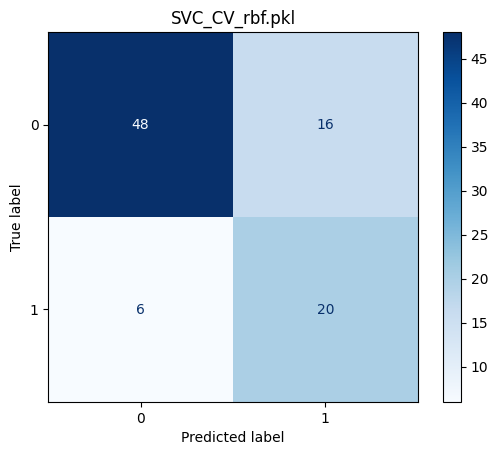

              precision    recall  f1-score   support

           0       0.89      0.75      0.81        64
           1       0.56      0.77      0.65        26

    accuracy                           0.76        90
   macro avg       0.72      0.76      0.73        90
weighted avg       0.79      0.76      0.76        90



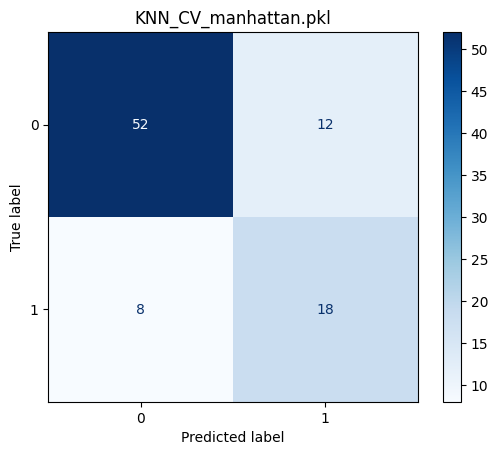

              precision    recall  f1-score   support

           0       0.87      0.81      0.84        64
           1       0.60      0.69      0.64        26

    accuracy                           0.78        90
   macro avg       0.73      0.75      0.74        90
weighted avg       0.79      0.78      0.78        90



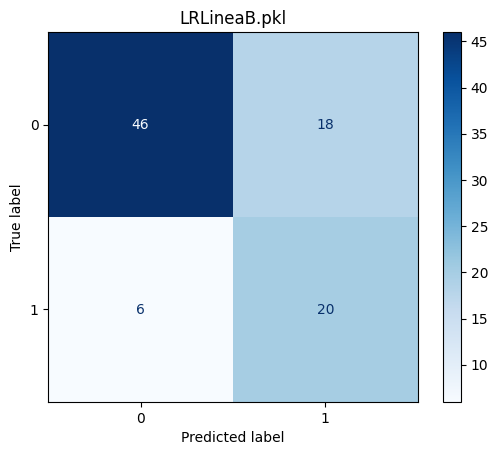

              precision    recall  f1-score   support

           0       0.88      0.72      0.79        64
           1       0.53      0.77      0.62        26

    accuracy                           0.73        90
   macro avg       0.71      0.74      0.71        90
weighted avg       0.78      0.73      0.74        90



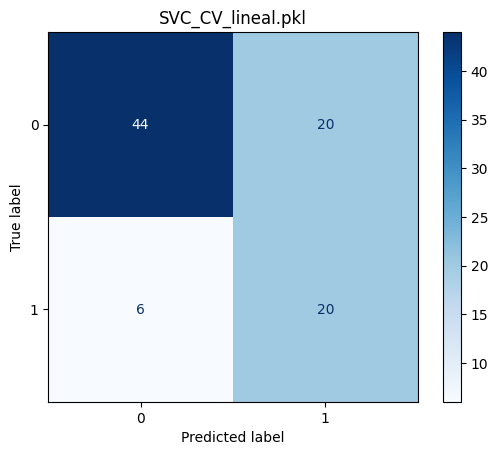

              precision    recall  f1-score   support

           0       0.88      0.69      0.77        64
           1       0.50      0.77      0.61        26

    accuracy                           0.71        90
   macro avg       0.69      0.73      0.69        90
weighted avg       0.77      0.71      0.72        90



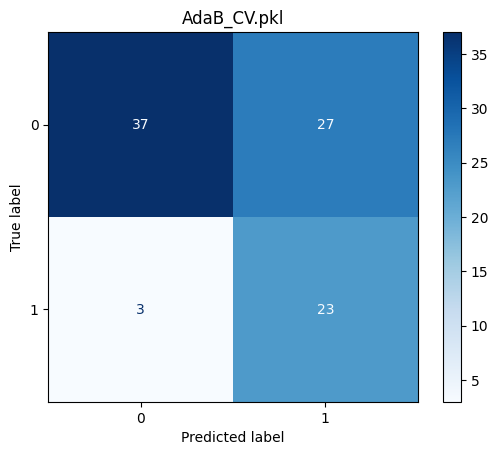

              precision    recall  f1-score   support

           0       0.93      0.58      0.71        64
           1       0.46      0.88      0.61        26

    accuracy                           0.67        90
   macro avg       0.69      0.73      0.66        90
weighted avg       0.79      0.67      0.68        90



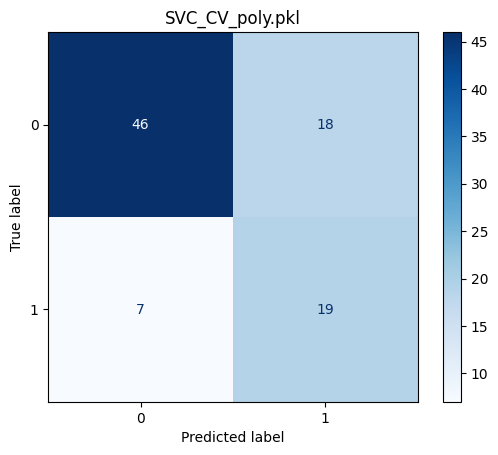

              precision    recall  f1-score   support

           0       0.87      0.72      0.79        64
           1       0.51      0.73      0.60        26

    accuracy                           0.72        90
   macro avg       0.69      0.72      0.69        90
weighted avg       0.77      0.72      0.73        90



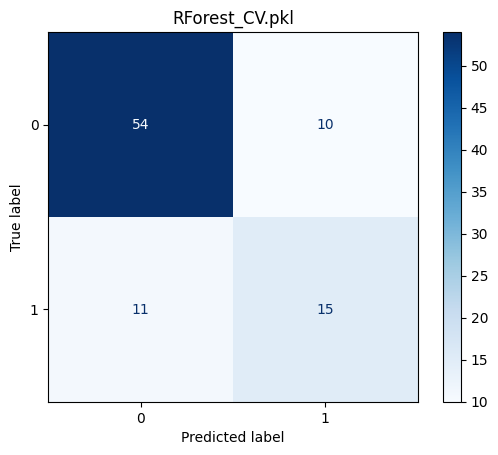

              precision    recall  f1-score   support

           0       0.83      0.84      0.84        64
           1       0.60      0.58      0.59        26

    accuracy                           0.77        90
   macro avg       0.72      0.71      0.71        90
weighted avg       0.76      0.77      0.77        90



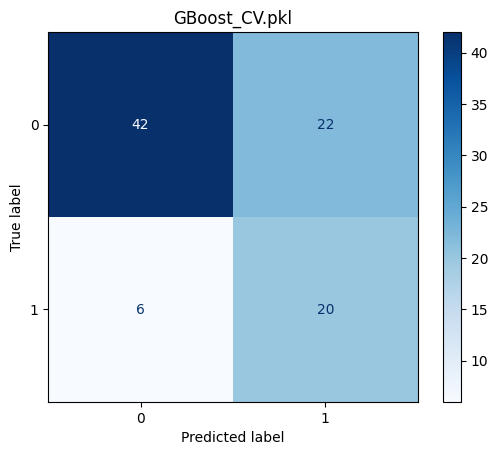

              precision    recall  f1-score   support

           0       0.88      0.66      0.75        64
           1       0.48      0.77      0.59        26

    accuracy                           0.69        90
   macro avg       0.68      0.71      0.67        90
weighted avg       0.76      0.69      0.70        90



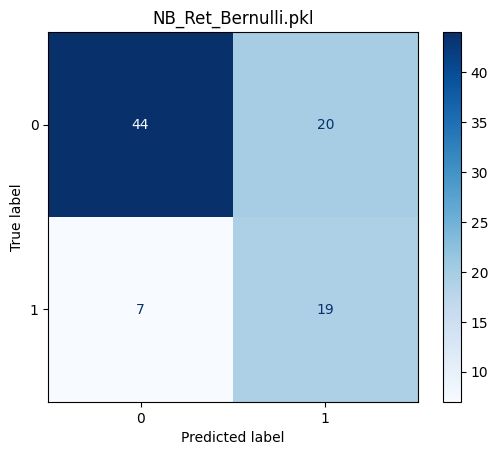

              precision    recall  f1-score   support

           0       0.86      0.69      0.77        64
           1       0.49      0.73      0.58        26

    accuracy                           0.70        90
   macro avg       0.67      0.71      0.67        90
weighted avg       0.75      0.70      0.71        90



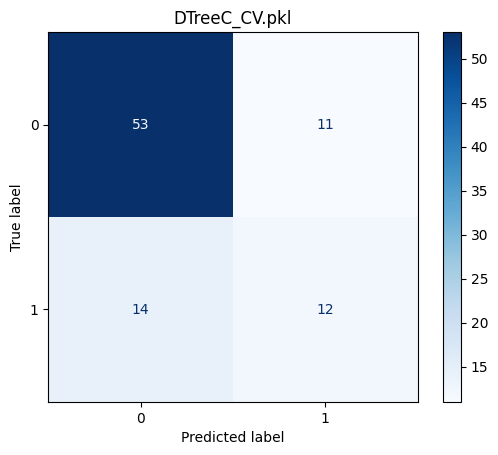

              precision    recall  f1-score   support

           0       0.79      0.83      0.81        64
           1       0.52      0.46      0.49        26

    accuracy                           0.72        90
   macro avg       0.66      0.64      0.65        90
weighted avg       0.71      0.72      0.72        90



In [50]:
for i, row in dr.sort_values(by='f1_score', ascending=False).iterrows():
    model_name = row['model']

    if archivo_modelo.endswith('.pkl'):
        ruta_completa = os.path.join(MODELS_CLASIFICATION_PATH, model_name)

        # Carga el modelo
        modelo_cargado = joblib.load(ruta_completa)

        # Realizar predicciones (opcional)
        y_pred = modelo_cargado.predict(Xp)

        # Calcular la matriz de confusión
        cm = confusion_matrix(yp, y_pred)

        # Crear la visualización de la matriz de confusión
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(yp))

        # Mostrar la visualización
        disp.plot(cmap='Blues')

        # Configurar el título
        plt.title(model_name)

        # Mostrar la figura
        plt.show()

        # Mostrar el informe de clasificación
        print(classification_report(yp, y_pred))


#### ROC - Receiver Operating Characteristic

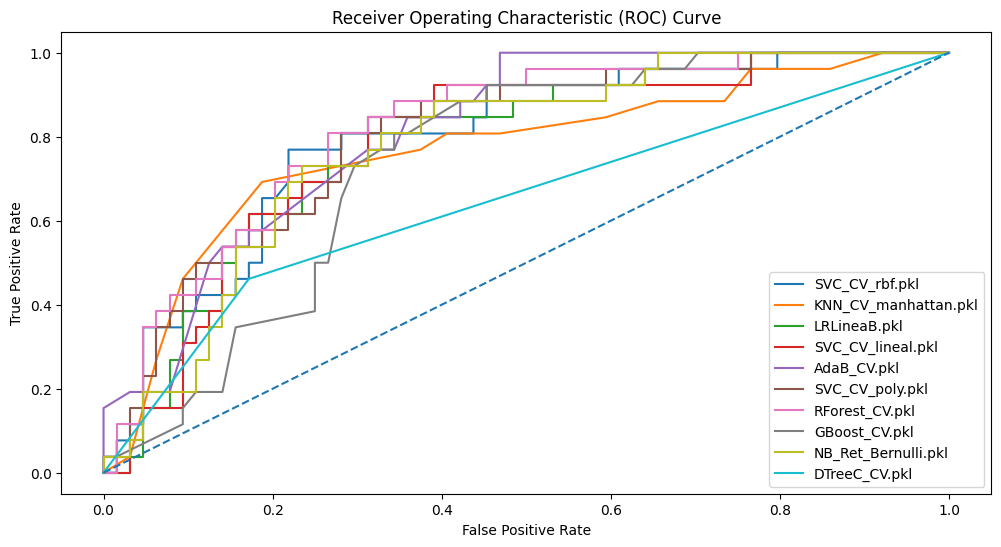

In [51]:
# Crear figura de tamaño 10x6
fig = plt.figure(figsize=(12, 6))


for i, row in dr.sort_values(by='f1_score', ascending=False).iterrows():
    model_name = row['model']

    if archivo_modelo.endswith('.pkl'):
        ruta_completa = os.path.join(MODELS_CLASIFICATION_PATH, model_name)

        # Carga el modelo
        modelo_cargado = joblib.load(ruta_completa)

        # Obtener probabilidades de predicción del modelo
        probs = modelo_cargado.predict_proba(Xp)

        # Seleccionar la columna correspondiente a la probabilidad de clase positiva
        probs = probs[:, 1]

        # Calcular el AUC-ROC
        auc = roc_auc_score(yp, probs*(1))

        # Calcular las tasas de FPR y TPR
        fpr, tpr, _ = roc_curve(yp, probs*(1))

        # Graficar la curva ROC del modelo actual
        plt.plot(fpr, tpr, label=model_name)

        # Mostrar el AUC-ROC y el nombre del modelo
        #print("{:.2f}: {}".format(auc, model_name))


# Graficar la línea diagonal punteada (clasificador aleatorio)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')  # Etiqueta del eje x
plt.ylabel('True Positive Rate')  # Etiqueta del eje y
plt.title('Receiver Operating Characteristic (ROC) Curve')  # Título del gráfico
plt.legend()  # Mostrar la leyenda de los modelos
plt.show()  # Mostrar el gráfico


#### Referencias


- *scikit-learn:*   
    - https://scikit-learn.org/stable/modules/svm.html
    
    ROC
    - https://stackabuse.com/understanding-roc-curves-with-python/



- *Gráficas con  seaborn:*
    - https://ichi.pro/es/como-utilizar-python-seaborn-para-analisis-de-datos-exploratorios-28897898172180



- *Analítica de grandes datos:*
    - https://jdvelasq.github.io/courses/analitica-de-grandes-datos/index.html